# PromptMOO: A Framework for Multi-Objective Prompt Optimization with Observable Gradients

This notebook runs Multi-Objective Prompt Optimization algorithms (GPO, OPRO, TextGrad) using Ray workers for parallelization.


## Setup


In [1]:
import sys
import os
from typing import Dict, List, Any
from datetime import datetime
import time

# Add paths for different environments
sys.path.append(f'{os.path.expanduser("~")}/PromptMOO/src/')
sys.path.insert(0, f'{os.path.expanduser("~")}/concurry/src/')
import concurry

import pandas as pd
from dotenv import load_dotenv

# Load environment variables
load_dotenv("_env")
assert os.getenv("OPENROUTER_API_KEY") not in {"", None}, "OPENROUTER_API_KEY not found"

print("✓ Environment loaded")

✓ Environment loaded


In [2]:
import os

output_dir = os.path.join(
    os.path.expanduser("~"),
    "PromptMOO/expt/outputs"
)

print(output_dir)

/jupyterhub/user/pdarshan/PromptMOO/expt/outputs


In [3]:
# Initialize Ray
import ray
import morphic
import concurry
import prompt_moo
import dataset
import runner
import time

# Initialize Ray with runtime environment
if not ray.is_initialized():
    ray.init(
        address='ray://127.0.0.1:10001',
        ignore_reinit_error=True,
        # log_to_driver=True, # Optional: for more verbose logging
        include_dashboard=False,
        _temp_dir='/tmp/ray_client/',
        runtime_env={"py_modules": [concurry, morphic, prompt_moo, dataset, runner]},
    )
    print("✓ Ray initialized")
else:
    print("✓ Ray already initialized")


2026-02-28 12:22:16,429	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: ignore_reinit_error, include_dashboard, log_to_driver
2026-02-28 12:22:16,673	INFO packaging.py:691 -- Creating a file package for local module '/home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/site-packages/concurry'.
2026-02-28 12:22:16,687	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_9779181357d9b2c4.zip' (1.20MiB) to Ray cluster...
2026-02-28 12:22:16,704	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_9779181357d9b2c4.zip'.
2026-02-28 12:22:16,713	INFO packaging.py:691 -- Creating a file package for local module '/home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/site-packages/morphic'.
2026-02-28 12:22:16,718	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_b9218a2df738e138.zip' (0.74MiB) to Ray cluster...
2026-02-28 12:22:16,727	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_b921

✓ Ray initialized


In [4]:
# Import runner components
from runner import AlgorithmRunner

print("✓ Runner components imported")

✓ Runner components imported


## Configuration


In [5]:
import os
from concurry import TaskWorker

def get_cwd():
    return os.getcwd()

task_worker = TaskWorker.options(mode='ray').init()
cwd_fututre = task_worker.submit(get_cwd)
remote_cwd = cwd_fututre.result()
task_worker.stop()

print(f'Remote worker cwd: {remote_cwd}')

Remote worker cwd: /root


In [6]:
from datetime import datetime
import os

EXPT_ID = "1_1"
EXPT_NAME = "SummEval-Batch_size=24_Loss_size=3_Gradient_size=4"
RUN_NAME = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

REMOTE_BASE = remote_cwd  # already: /home/ubuntu/miniconda3/envs/prompt_moo/lib/python3.12
BASE_OUTPUT = os.path.join(output_dir, "outputs", EXPT_NAME, EXPT_ID)
print(BASE_OUTPUT)

/jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1


In [7]:
# Define what to run
DATASETS = [
    "SummEval", 
]
ALGORITHMS = [
    ("opro", {}),
    # ("textgrad", {})
    ("gpo", {}),
]
LLMS = [
    "llama3.1",
    "qwen3",
]  
RUN_NAME = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
from dataset import Dataset

experiments = []

for dataset_name in DATASETS:
    for algo, algo_kwargs in ALGORITHMS:
        for llm in LLMS:

            run_dir = f"{algo.upper()}_{dataset_name}_{RUN_NAME}"
            output_dir = os.path.join(BASE_OUTPUT, run_dir)

            experiments.append({
                "dataset": Dataset.of(
                    dataset_name,
                    data_dir="/jupyterhub/user/pdarshan/PromptMOO/expt/",
                ),
                "dataset_name": dataset_name,
                "algorithm": algo,
                "steps": 10,
                "llm": llm,
                "api_key": os.getenv("OPENROUTER_API_KEY"),
                "batch_size": 24,
                "loss_batch_size": 3,
                "gradient_batch_size": 4,
                "eval_every": 5,
                "output_dir": output_dir,   
                **algo_kwargs,
            })

print(f"Total experiments to run: {len(experiments)}")
print(f"Run name: {RUN_NAME}")
print(f"LLMs to test: {LLMS}")
print("\nExperiments:")
for i, exp in enumerate(experiments, 1):
    print(f"  {i}. {exp['algorithm']:10s} on {exp['dataset_name']:10s} with {exp['llm']}")

Total experiments to run: 4
Run name: run_20260228_122227
LLMs to test: ['llama3.1', 'qwen3']

Experiments:
  1. opro       on SummEval   with llama3.1
  2. opro       on SummEval   with qwen3
  3. gpo        on SummEval   with llama3.1
  4. gpo        on SummEval   with qwen3


## Initialize Ray Workers


In [8]:
from concurry import ExecutionMode

# Initialize AlgorithmRunner worker pool using Ray
# Each worker uses X CPU
CPUS_PER_JOB = 4
runner_pool = AlgorithmRunner.options(
    mode="ray",
    max_workers=len(experiments),  # One worker per experiment
    actor_options={"num_cpus": CPUS_PER_JOB},
    
    # mode="sync",
    # max_workers=1, 
).init()

if runner_pool.mode == ExecutionMode.Ray:
    print(f"✓ Initialized Ray worker pool with {len(experiments)} workers")
    print(f"  Each worker allocated: {CPUS_PER_JOB} CPU")
    print(f"  Total CPU allocation: {len(experiments) * CPUS_PER_JOB:.1f}")


✓ Initialized Ray worker pool with 4 workers
  Each worker allocated: 4 CPU
  Total CPU allocation: 16.0


(AlgorithmRunner_WithLimits pid=2054255) [2026-02-28 12:22:49,226 E 2054255 2054398] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


In [9]:
# from concurry import ExecutionMode

# # Initialize AlgorithmRunner worker pool
# runner_pool = AlgorithmRunner.options(
#     mode="processes",
#     max_workers=len(experiments),  # One worker per experiment
# ).init()

In [10]:
experiments[0]['dataset']

SummEval(data_dir='/jupyterhub/user/pdarshan/PromptMOO/expt/')

In [11]:
experiments[0]['llm']

'llama3.1'

## Submit Jobs


In [12]:
from morphic.string import hash as hash_str
# Submit all experiments to Ray workers
futures = {}

print("Submitting jobs to workers...\n")

for exp in experiments:
    exp_key = f"{exp['dataset_name']}_{exp['algorithm']}_{exp['llm']}_{hash_str(exp)[:6]}"
    print(f"  Submitting: {exp_key}")
    print(f"    Output dir: {exp['output_dir']}")
    future = runner_pool.run(
        run_name=RUN_NAME,
        dataset=exp['dataset'],
        output_dir=exp['output_dir'],
        algo_name=exp['algorithm'],
        llm=exp['llm'],
        steps=exp['steps'],
        api_key=exp['api_key'],
        batch_size=exp['batch_size'],
        loss_batch_size=exp['loss_batch_size'],
        gradient_batch_size=exp['gradient_batch_size'],
        eval_every=exp['eval_every'],
        verbosity=1,
    )
    futures[exp_key] = future
    time.sleep(5)

print(f"\n✓ Submitted {len(futures)} jobs")
print("\nJobs are now running in parallel. Monitor progress below...")

Submitting jobs to workers...

  Submitting: SummEval_opro_llama3.1_opEDOr
    Output dir: /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227


Training:   0%|                                                             | 0/10 [00:00<?, ?row/s]


(AlgorithmRunner_WithLimits pid=2054255) [AlgorithmRunner] Starting opro on SummEval (run: run_20260228_122227, llm: llama3.1)
(AlgorithmRunner_WithLimits pid=2054255) Output directory: /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227
  Submitting: SummEval_opro_qwen3_gMq3Zy
    Output dir: /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227


Training:   0%|                                                             | 0/10 [00:00<?, ?row/s]


(AlgorithmRunner_WithLimits pid=2054476) [AlgorithmRunner] Starting opro on SummEval (run: run_20260228_122227, llm: qwen3)
(AlgorithmRunner_WithLimits pid=2054476) Output directory: /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227
  Submitting: SummEval_gpo_llama3.1_xvHuGt
    Output dir: /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/GPO_SummEval_run_20260228_122227


...

(AlgorithmRunner_WithLimits pid=2054255) [Observer] Appended step 2 -> /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227/run_logs.parquet


(AlgorithmRunner_WithLimits pid=2054476) Usage (1816) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054476) Usage (1883) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054476) Usage (1960) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054476) Usage (1407) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (100000

(AlgorithmRunner_WithLimits pid=2054255) [Observer] Appended step 3 -> /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227/run_logs.parquet


(AlgorithmRunner_WithLimits pid=2054477) /home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/_weakrefset.py:88: RuntimeWarning: coroutine 'BaseLLMHTTPHandler.async_completion' was never awaited
(AlgorithmRunner_WithLimits pid=2054477)   self.data.add(ref(item, self._remove))
(AlgorithmRunner_WithLimits pid=2054477) RuntimeWarning: Enable tracemalloc to get the object allocation traceback
Training:  10%|█████▏                                              | 1/10 [02:33<22:59, 153.30s/row]


(AlgorithmRunner_WithLimits pid=2054476) Failed to parse task response for sample step0_sample432:
(AlgorithmRunner_WithLimits pid=2054476) ValueError: "No JSON found in response:
(AlgorithmRunner_WithLimits pid=2054476) "
(AlgorithmRunner_WithLimits pid=2054476) Traceback:
(AlgorithmRunner_WithLimits pid=2054476) 	/tmp/ray/session_2026-02-28_11-48-15_698321_1869951/runtime_resources/py_modules_files/_ray_pkg_3cb7757a51d9b963/prompt_moo/task_predictor.py line 162, in predict...
(AlgorithmRunner_WithLimits pid=2054476) 	/tmp/ray/session_2026-02-28_11-48-15_698321_1869951/runtime_resources/py_modules_files/_ray_pkg_3cb7757a51d9b963/prompt_moo/task_predictor.py line 40, in parse_task_response...
(AlgorithmRunner_WithLimits pid=2054476) [Observer] Saved evaluation results → /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227/eval_step_0.parquet
(AlgorithmRunner_WithLimits pid=2054476) [Observer] A

## Monitor Progress

You can monitor progress by:
1. **Running Cell below**: Shows completion status
2. **Output directories**: Check `outputs/` for results as they complete


In [13]:
# Check status of all jobs
import time
from concurry import wait

print("Monitoring job progress...\n")
print("(You can interrupt this cell and re-run it to check status)\n")

completed = 0
failed = 0
total = len(futures)

while completed + failed < total:
    # Check which jobs are done
    try:
        done, not_done = wait(list(futures.values()), timeout=5.0, return_when="FIRST_COMPLETED")
    except TimeoutError as e:
        break
    
    # Count completed jobs
    for future in done:
        try:
            result = future.result(timeout=0.1)
            if result.get('status') == 'success':
                completed += 1
                print(f"✓ Completed: {result['dataset']:10s} + {result['algorithm']:10s} ({completed}/{total})")
            else:
                failed += 1
                print(f"✗ Failed: {result['dataset']:10s} + {result['algorithm']:10s} - {result.get('error', 'Unknown error')}")
        except Exception as e:
            failed += 1
            print(f"✗ Error getting result: {e}")
    
    # Update progress
    remaining = total - completed - failed
    if remaining > 0:
        print(f"\nProgress: {completed} completed, {failed} failed, {remaining} remaining...")
        time.sleep(10)  # Check every 10 seconds

print(f"\n{'='*60}")
print(f"  Completed: {completed}/{total}")
print(f"  Failed: {failed}/{total}")
print(f"{'='*60}")


Monitoring job progress...

(You can interrupt this cell and re-run it to check status)


  Completed: 0/4
  Failed: 0/4


Training:  50%|██████████████████████████▌                          | 5/10 [02:51<02:25, 29.00s/row]


(AlgorithmRunner_WithLimits pid=2054255) [Observer] Appended step 4 -> /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227/run_logs.parquet


(AlgorithmRunner_WithLimits pid=2054476) Usage (1293) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054477) 12:26:09 - LiteLLM:ERROR: logging_worker.py:77 - LoggingWorker error: 
(AlgorithmRunner_WithLimits pid=2054477) Traceback (most recent call last):
(AlgorithmRunner_WithLimits pid=2054477)   File "/home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/asyncio/tasks.py", line 507, in wait_for
(AlgorithmRunner_WithLimits pid=2054477)     return await fut
(AlgorithmRunner_WithLimits pid=2054477)            ^^^^^^^^^
(AlgorithmRunner_WithLimits pid=2054477) asyncio.exceptions.CancelledError
(AlgorithmRunner_WithLimits pid=2054477) 
(AlgorithmRunner_WithLimits pid=2054477) The above exception was the direct cause of the following exception:
(AlgorithmRunner_WithLimits pid=2054477) 
(AlgorithmRunner_WithLim

(AlgorithmRunner_WithLimits pid=2054476) [Observer] Appended step 1 -> /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227/run_logs.parquet


...

(AlgorithmRunner_WithLimits pid=2054476) Usage (1047) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054476) Usage (1207) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054477) 12:37:32 - LiteLLM:ERROR: logging_worker.py:77 - LoggingWorker error: 
(AlgorithmRunner_WithLimits pid=2054477) Traceback (most recent call last):
(AlgorithmRunner_WithLimits pid=2054477)   File "/home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/asyncio/tasks.py", line 507, in wait_for
(AlgorithmRunner_WithLimits pid=2054477)     return await fut
(AlgorithmRunner_WithLimits pid=2054477)            ^^^^^^^^^
(AlgorithmRunner_WithLimits pid=2054477) a

(AlgorithmRunner_WithLimits pid=2054476) [Observer] Appended step 8 -> /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/OPRO_SummEval_run_20260228_122227/run_logs.parquet
(AlgorithmRunner_WithLimits pid=2054476) [Observer] Pruned 1 old step(s) from memory, keeping last 5


(AlgorithmRunner_WithLimits pid=2054477) 12:40:35 - LiteLLM:ERROR: logging_worker.py:77 - LoggingWorker error: 
(AlgorithmRunner_WithLimits pid=2054477) Traceback (most recent call last):
(AlgorithmRunner_WithLimits pid=2054477)   File "/home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/asyncio/tasks.py", line 507, in wait_for
(AlgorithmRunner_WithLimits pid=2054477)     return await fut
(AlgorithmRunner_WithLimits pid=2054477)            ^^^^^^^^^
(AlgorithmRunner_WithLimits pid=2054477) asyncio.exceptions.CancelledError
(AlgorithmRunner_WithLimits pid=2054477) 
(AlgorithmRunner_WithLimits pid=2054477) The above exception was the direct cause of the following exception:
(AlgorithmRunner_WithLimits pid=2054477) 
(AlgorithmRunner_WithLimits pid=2054477) Traceback (most recent call last):
(AlgorithmRunner_WithLimits pid=2054477)   File "/home/ubuntu/miniconda3/envs/promptmoo/lib/python3.13/site-packages/litellm/litellm_core_utils/logging_worker.py", line 72, in _worker_loop
(Algorithm

(AlgorithmRunner_WithLimits pid=2054477) [Observer] Error logged → /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/GPO_SummEval_run_20260228_122227/run_summary.json
(AlgorithmRunner_WithLimits pid=2054477) [AlgorithmRunner] Failed gpo on SummEval:
(AlgorithmRunner_WithLimits pid=2054477) Timeout: "litellm.Timeout: Timeout Error: OpenrouterException - litellm.Timeout: Connection timed out. Timeout passed=59.0, time taken=107.861 seconds"
(AlgorithmRunner_WithLimits pid=2054477) Traceback:
(AlgorithmRunner_WithLimits pid=2054477) 	/tmp/ray/session_2026-02-28_11-48-15_698321_1869951/runtime_resources/py_modules_files/_ray_pkg_3f1072ba96fb22b6/runner.py line 679, in run...
(AlgorithmRunner_WithLimits pid=2054477) 	/tmp/ray/session_2026-02-28_11-48-15_698321_1869951/runtime_resources/py_modules_files/_ray_pkg_3cb7757a51d9b963/prompt_moo/algorithm.py line 287, in train...
(AlgorithmRunner_WithLimits pid=2054477) 	/tmp/ray/sessio

(AlgorithmRunner_WithLimits pid=2054476) Usage (1048) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054476) Usage (1110) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).
(AlgorithmRunner_WithLimits pid=2054476) Usage (1069) exceeds requested amount (1024) for limit 'output_tokens'. This may indicate incorrect usage tracking or unexpected token consumption. Excess usage will be constrained by limit capacity (1000000).


## Collect Results


In [ ]:
# Collect all results
results = {}

for exp_key, future in futures.items():
    try:
        result = future.result(timeout=1.0)
        results[exp_key] = result
    except Exception as e:
        results[exp_key] = {
            "status": "error",
            "error": str(e)
        }

print(f"Collected {len(results)} results\n")

# Create summary DataFrame
summary_data = []
for exp_key, result in results.items():
    summary_data.append({
        "experiment": exp_key,
        "dataset": result.get('dataset', '?'),
        "algorithm": result.get('algorithm', '?'),
        "status": result.get('status', 'unknown'),
        "error": result.get('error', None),
    })

summary_df = pd.DataFrame(summary_data)
summary_df


In [ ]:
results

In [ ]:
results['SummEval_gpo_llama3.1']['results']['run_logs']

In [19]:
from runner import resume_failed_runs

# Resume failed experiments
resumed_futures = resume_failed_runs(
    futures=futures,
    experiments=experiments,
    runner_pool=runner_pool,
    run_name=RUN_NAME,
)

print(f"\n✓ Resumed {len(resumed_futures)} failed runs")


✓ Resumed 0 failed runs


In [ ]:
# Save summary to file
summary_file = f"outputs/run_summary_{RUN_NAME}.csv"
os.makedirs("outputs", exist_ok=True)
summary_df.to_csv(summary_file, index=False)
print(f"✓ Saved summary to: {summary_file}")


## Cleanup


In [ ]:
# Stop worker pool
runner_pool.stop()
print("✓ Worker pool stopped")

# Note: Ray cluster is kept running for potential re-use
# To shutdown Ray completely, run: ray.shutdown()


## Analysis

Results have been saved to the `outputs/` directory. 
- Compare algorithm performance
- Plot learning curves
- Analyze prompt evolution
- Generate summary statistics

The cells below load completed run results and produce visualizations.
These can be run independently of the training cells above.

In [39]:
! ls {BASE_OUTPUT} | head -2

GPO_SummEval_run_20260228_122227
OPRO_SummEval_run_20260228_122227


I0000 00:00:1772279464.156402 2054012 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


In [56]:
### --- Load a completed run and plot learning curves ---
import pandas as pd
import os

# Point to a completed GPO run directory
RUN_DIR = os.path.join(BASE_OUTPUT, "GPO_SummEval_run_20260228_122227")  # <-- UPDATE with actual run dir

# Load run logs
run_logs = pd.read_parquet(os.path.join(RUN_DIR, "run_logs.parquet"))
print(f"Loaded {len(run_logs)} steps from: {RUN_DIR}")
print(f"Columns: {list(run_logs.columns)}")
run_logs.head()

Loaded 5 steps from: /jupyterhub/user/pdarshan/PromptMOO/expt/outputs/outputs/SummEval-Batch_size=24_Loss_size=3_Gradient_size=4/1_1/GPO_SummEval_run_20260228_122227
Columns: ['step', 'timestamp', 'batch', 'predictions', 'algorithm_context', 'feedbacks', 'gradients', 'prompt_update', 'algorithm_state', 'evaluation']


,step,timestamp,batch,predictions,algorithm_context,feedbacks,gradients,prompt_update,algorithm_state,evaluation
0,0,2026-02-28T12:23:10.718237,"{""step"": 0, ""num_samples"": 24, ""samples"": [{""s...","{""num_predictions"": 24, ""predictions"": [{""samp...","{""warmup_steps"": 5, ""total_steps"": 10, ""use_wa...","{""num_tasks"": 4, ""feedbacks"": {""fluency"": [{""t...","{""num_tasks"": 4, ""gradients"": {""fluency"": [{""t...","{""old_prompt_file"": ""prompts/step_0_old.txt"", ...","{""trajectory"": [{""loss_fns"": {""fluency"": {""met...","{""step"": 0, ""results_file"": ""/jupyterhub/user/..."
1,1,2026-02-28T12:30:06.265921,"{""step"": 1, ""num_samples"": 24, ""samples"": [{""s...","{""num_predictions"": 24, ""predictions"": [{""samp...","{""warmup_steps"": 5, ""total_steps"": 10, ""use_wa...","{""num_tasks"": 4, ""feedbacks"": {""fluency"": [{""t...","{""num_tasks"": 4, ""gradients"": {""fluency"": [{""t...","{""old_prompt_file"": ""prompts/step_1_old.txt"", ...","{""trajectory"": [{""loss_fns"": {""fluency"": {""met...",None
2,2,2026-02-28T12:31:01.251923,"{""step"": 2, ""num_samples"": 24, ""samples"": [{""s...","{""num_predictions"": 24, ""predictions"": [{""samp...","{""warmup_steps"": 5, ""total_steps"": 10, ""use_wa...","{""num_tasks"": 4, ""feedbacks"": {""fluency"": [{""t...","{""num_tasks"": 4, ""gradients"": {""fluency"": [{""t...","{""old_prompt_file"": ""prompts/step_2_old.txt"", ...","{""trajectory"": [{""loss_fns"": {""fluency"": {""met...",None
3,3,2026-02-28T12:31:59.142447,"{""step"": 3, ""num_samples"": 24, ""samples"": [{""s...","{""num_predictions"": 24, ""predictions"": [{""samp...","{""warmup_steps"": 5, ""total_steps"": 10, ""use_wa...","{""num_tasks"": 4, ""feedbacks"": {""fluency"": [{""t...","{""num_tasks"": 4, ""gradients"": {""fluency"": [{""t...","{""old_prompt_file"": ""prompts/step_3_old.txt"", ...","{""trajectory"": [{""loss_fns"": {""fluency"": {""met...",None
4,4,2026-02-28T12:32:54.972259,"{""step"": 4, ""num_samples"": 24, ""samples"": [{""s...","{""num_predictions"": 24, ""predictions"": [{""samp...","{""warmup_steps"": 5, ""total_steps"": 10, ""use_wa...","{""num_tasks"": 4, ""feedbacks"": {""fluency"": [{""t...","{""num_tasks"": 4, ""gradients"": {""fluency"": [{""t...","{""old_prompt_file"": ""prompts/step_4_old.txt"", ...","{""trajectory"": [{""loss_fns"": {""fluency"": {""met...",None


In [57]:
### --- Show example prompts: initial vs optimized ---
import json
# Load the run summary to get prompts
run_summary_path = os.path.join(RUN_DIR, "run_summary.json")
with open(run_summary_path) as f:
    run_summary = json.load(f)

# Initial prompt
initial_prompt = run_summary.get('config', {}).get('initial_prompt', 'N/A')
print("=" * 80)
print("INITIAL PROMPT:")
print("=" * 80)
print(initial_prompt)

# Final prompt (from last step's prompt_update)
last_step = run_logs.iloc[-1]
with open(os.path.join(RUN_DIR, json.loads(last_step['prompt_update'])['new_prompt_file'])) as f:
    final_prompt = f.read()
    print("\n" + "=" * 80)
    print("OPTIMIZED PROMPT (final step):")
    print("=" * 80)
    print(str(final_prompt))

INITIAL PROMPT:
Evaluate the summary. Output JSON with the requested metric scores. Do NOT include reasoning or explanations. Each metric should contain a single integer. Formats like '4/5' or '4|5' are invalid.
Output the following metrics: fluency, relevance, coherence, consistency.
Output format (follow this EXACTLY):
{
  "fluency": An Integer between 1 to 5,
  "relevance": An Integer between 1 to 5,
  "coherence": An Integer between 1 to 5,
  "consistency": An Integer between 1 to 5
}

## Tasks:
 - Task name: fluency
Task description: Evaluate the fluency and readability of the summary
Task instruction: Rate the fluency of this summary on a scale from 1 (very poor) to 5 (excellent). Consider grammar, flow, and readability.
- Task name: relevance
Task description: Evaluate whether the summary captures the most important information from the source text
Task instruction: Rate the relevance of this summary on a scale from 1 (not relevant) to 5 (highly relevant). Consider if it capture

In [58]:
json.loads(run_logs.query('step == 4')['gradients'].iloc[0])

{'num_tasks': 4,
 'gradients': {'fluency': [{'task_name': 'fluency',
    'gradient_text': 'To improve the instructions for the fluency task, consider adding more specific examples and guidelines to help annotators better understand the nuances of fluency evaluation. Emphasize the importance of balancing criticism with leniency, recognizing that minor errors do not necessarily detract from overall readability and flow. Additionally, provide clearer criteria for distinguishing between excellent (score 5) and good (score 4) fluency, and encourage annotators to prioritize overall coherence and clarity in their evaluations.',
    'based_on_feedbacks': ['step4_sample1',
     'step4_sample0',
     'step4_sample2',
     'step4_sample4',
     'step4_sample5',
     'step4_sample3',
     'step4_sample6',
     'step4_sample7',
     'step4_sample8',
     'step4_sample9',
     'step4_sample11',
     'step4_sample10'],
    'gradient_prompt': None},
   {'task_name': 'fluency',
    'gradient_text': "To

In [60]:
### --- Gradient conflict analysis: cosine similarity heatmap ---
import numpy as np
from sentence_transformers import SentenceTransformer
import json

# Load gradient texts from run logs
gradient_texts_by_task = {}  # {task_name: [list of gradient texts across steps]}

for _, row in run_logs.iterrows():
    gradients = row.get('gradients')
    if gradients is None:
        continue
    if isinstance(gradients, str):
        gradients = json.loads(gradients)
    
    for task_name, grad_text in gradients.items():
        if task_name not in gradient_texts_by_task:
            gradient_texts_by_task[task_name] = []
        text = grad_text if isinstance(grad_text, str) else str(grad_text)
        gradient_texts_by_task[task_name].append(text)

tasks = sorted(gradient_texts_by_task.keys())
print(f"Tasks with gradients: {tasks}")
print(f"Gradient texts per task: {[len(gradient_texts_by_task[t]) for t in tasks]}")

Tasks with gradients: ['gradients', 'num_tasks']
Gradient texts per task: [5, 5]


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

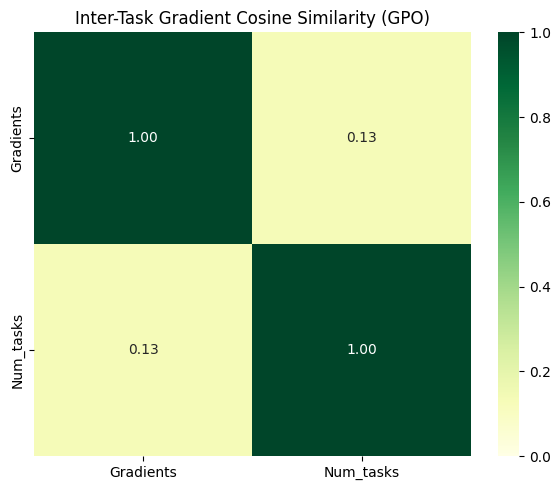

Saved: gradient_similarity.pdf


In [63]:
### --- 5. Compute and plot cosine similarity heatmap ---
import matplotlib.pyplot as plt
import seaborn as sns

model = SentenceTransformer('all-MiniLM-L6-v2')

# Embed all gradient texts per task (average across steps)
task_embeddings = {}
for task in tasks:
    texts = gradient_texts_by_task[task]
    embeddings = model.encode(texts)
    task_embeddings[task] = embeddings.mean(axis=0)  # average embedding

# Compute pairwise cosine similarity
n = len(tasks)
sim_matrix = np.zeros((n, n))
for i, t1 in enumerate(tasks):
    for j, t2 in enumerate(tasks):
        e1, e2 = task_embeddings[t1], task_embeddings[t2]
        sim_matrix[i, j] = np.dot(e1, e2) / (np.linalg.norm(e1) * np.linalg.norm(e2))

# Plot heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    sim_matrix,
    xticklabels=[t.capitalize() for t in tasks],
    yticklabels=[t.capitalize() for t in tasks],
    annot=True, fmt=".2f",
    cmap="YlGn", vmin=0, vmax=1,
    ax=ax,
)
ax.set_title("Inter-Task Gradient Cosine Similarity (GPO)")
plt.tight_layout()
plt.savefig("gradient_similarity.pdf", bbox_inches='tight')
plt.show()
print("Saved: gradient_similarity.pdf")